# Exploratory Data Analysis (EDA) Cheat Sheet
This notebook summarizes key EDA techniques, statistical analysis, and visualization steps.

## Task 1 - Data Preparation
Load dataset and check general info.

In [5]:

import pandas as pd

df = pd.read_csv("EDA_laptops.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      238 non-null    int64  
 1   Unnamed: 0        238 non-null    int64  
 2   Manufacturer      238 non-null    object 
 3   Category          238 non-null    int64  
 4   GPU               238 non-null    int64  
 5   OS                238 non-null    int64  
 6   CPU_core          238 non-null    int64  
 7   Screen_Size_inch  238 non-null    float64
 8   CPU_frequency     238 non-null    float64
 9   RAM_GB            238 non-null    int64  
 10  Storage_GB_SSD    238 non-null    int64  
 11  Weight_pounds     238 non-null    float64
 12  Price             238 non-null    int64  
 13  Price-binned      238 non-null    object 
 14  Screen-Full_HD    238 non-null    int64  
 15  Screen-IPS_panel  238 non-null    int64  
dtypes: float64(3), int64(11), object(2)
memory u

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


## Task 2 - Descriptive Statistical Analysis
Generate statistical description for both numerical and object data types.

In [6]:

desc_numeric = df.describe()
desc_object = df.describe(include=['object'])
desc_numeric, desc_object


(       Unnamed: 0.1  Unnamed: 0    Category         GPU          OS  \
 count    238.000000  238.000000  238.000000  238.000000  238.000000   
 mean     118.500000  118.500000    3.205882    2.151261    1.058824   
 std       68.848868   68.848868    0.776533    0.638282    0.235790   
 min        0.000000    0.000000    1.000000    1.000000    1.000000   
 25%       59.250000   59.250000    3.000000    2.000000    1.000000   
 50%      118.500000  118.500000    3.000000    2.000000    1.000000   
 75%      177.750000  177.750000    4.000000    3.000000    1.000000   
 max      237.000000  237.000000    5.000000    3.000000    2.000000   
 
          CPU_core  Screen_Size_inch  CPU_frequency      RAM_GB  \
 count  238.000000        238.000000     238.000000  238.000000   
 mean     5.630252         14.688655       0.813822    7.882353   
 std      1.241787          1.166045       0.141860    2.482603   
 min      3.000000         12.000000       0.413793    4.000000   
 25%      5.000

## Task 3 - GroupBy and Pivot Tables
Group data by GPU and CPU_core, calculate mean Price, and visualize using pcolor plot.

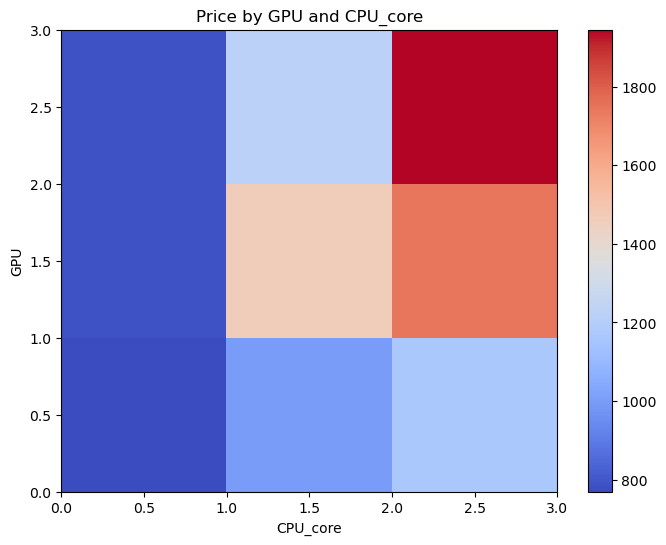

In [7]:

import matplotlib.pyplot as plt

df_gptest = df[['GPU', 'CPU_core', 'Price']]
grouped_test1 = df_gptest.groupby(['GPU', 'CPU_core'], as_index=False).mean()
grouped_pivot = grouped_test1.pivot(index='GPU', columns='CPU_core', values='Price')

plt.figure(figsize=(8,6))
plt.pcolor(grouped_pivot, cmap='coolwarm')
plt.colorbar()
plt.title('Price by GPU and CPU_core')
plt.xlabel('CPU_core')
plt.ylabel('GPU')
plt.show()


## Task 4 - Pearson Correlation and p-values
Evaluate Pearson Coefficient and p-values for numerical parameters to assess their effect on Price.

In [8]:

from scipy import stats

features = ['Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_pounds']
for feature in features:
    pearson_coef, p_value = stats.pearsonr(df[feature], df['Price'])
    print(f"Feature: {feature}")
    print(f"Pearson Coefficient = {pearson_coef:.3f}, P-value = {p_value:.3e}\n")


Feature: Screen_Size_inch
Pearson Coefficient = -0.111, P-value = 8.853e-02

Feature: CPU_frequency
Pearson Coefficient = 0.367, P-value = 5.502e-09

Feature: RAM_GB
Pearson Coefficient = 0.549, P-value = 3.682e-20

Feature: Storage_GB_SSD
Pearson Coefficient = 0.243, P-value = 1.490e-04

Feature: Weight_pounds
Pearson Coefficient = -0.050, P-value = 4.398e-01



## Task 5 - Visualization Summary
Summarize EDA insights and visualize correlations.

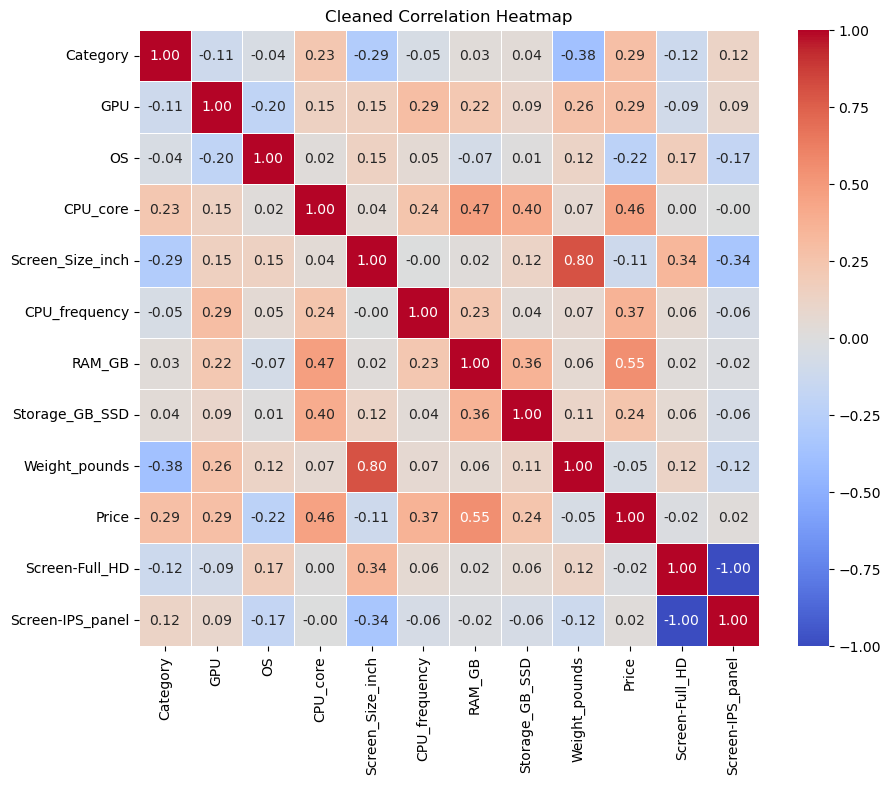

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

correlation_matrix = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)

plt.title('Cleaned Correlation Heatmap')
plt.show()